# **Experiment: Industry Cleaning**

## **Objective**

Đánh giá liệu việc chuẩn hóa và gom nhóm biến `industry` bằng hàm `clean_industry()` có cải thiện hiệu năng dự đoán lương hay không.

## **Experiment Design**

Hai phiên bản **Feature Set A** được so sánh:

1. Original Industry
2. Cleaned Industry

Mô hình sử dụng:

- Ridge Regression
- Stratified 5-Fold Cross Validation
- MAE
- RMSE

## **Hypothesis**

Việc chuẩn hóa và gộp nhóm Industry có thể giảm hiện tượng **high-cardinality**, hạn chế **sparsity** sau **One-Hot Encoding** và cải thiện khả năng tổng quát hóa của mô hình `Ridge Regression`.

## **SECTION 1 - Load Data**

### Load Data

Tải dữ liệu đã được tiền xử lý từ bước Data Processing và import các thư viện cần thiết cho quá trình xây dựng mô hình.

In [35]:
import os
import sys
# Thêm đường dẫn để import từ thư mục src
sys.path.append(os.path.abspath(os.path.join('..')))
from src.evaluation import (evaluate_model,get_model_summary)
from src.processor import (group_rare_categories, clean_industry)
from src.modeling import (tune_ridge_alpha, build_ridge_pipeline)

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
warnings.filterwarnings("ignore")


In [37]:
jobs = pd.read_parquet("../data/processed/jobs_cleaned.parquet")
skills = pd.read_parquet("../data/processed/skills.parquet")

print(jobs.shape)
print(skills.shape)

(3181, 27)
(56335, 8)


## **SECTION 2 - Target Engineering**

Để đảm bảo khả năng so sánh với notebook chính, toàn bộ quy trình xử lý biến mục tiêu được giữ nguyên.

###  **2.1 Negotiable Analysis**

In [38]:
jobs.groupby("is_thoa_thuan")["source"].value_counts(normalize=True)

is_thoa_thuan  source
False          topcv     0.879567
               itviec    0.120433
True           topcv     0.669407
               itviec    0.330593
Name: proportion, dtype: float64

In [39]:
jobs.groupby("is_thoa_thuan")["job_level"].value_counts(normalize=True)

is_thoa_thuan  job_level         
False          Nhân viên             0.609608
               Trưởng nhóm           0.217185
               Intern                0.074425
               Senior                0.041949
               Quản lý / Giám sát    0.031800
               Trưởng/Phó phòng      0.018268
               Junior                0.004060
               Giám đốc              0.002030
               Fresher               0.000677
True           Nhân viên             0.597769
               Trưởng nhóm           0.159131
               Senior                0.112155
               Quản lý / Giám sát    0.049325
               Intern                0.032883
               Trưởng/Phó phòng      0.030534
               Junior                0.012918
               Giám đốc              0.003523
               Fresher               0.001762
Name: proportion, dtype: float64

### **Decision 1**

#### **2.1.1 Remove Negotiable Salaries**

In [40]:
jobs_model = jobs[jobs["is_thoa_thuan"] == False].copy()
print("Remaining jobs:", jobs_model.shape)

Remaining jobs: (1478, 27)


#### **2.1.2 Examine Salary Distribution**

In [41]:
jobs_model["avg_salary"].describe(
    percentiles=[
        0.90,
        0.95,
        0.97,
        0.99,
        0.995
    ]
)

count      1478.000000
mean        236.848241
std        7217.937359
min           0.000000
50%          22.500000
90%          47.500000
95%          56.250000
97%          63.231400
99%          75.000000
99.5%        86.037800
max      275000.000000
Name: avg_salary, dtype: float64

<Axes: >

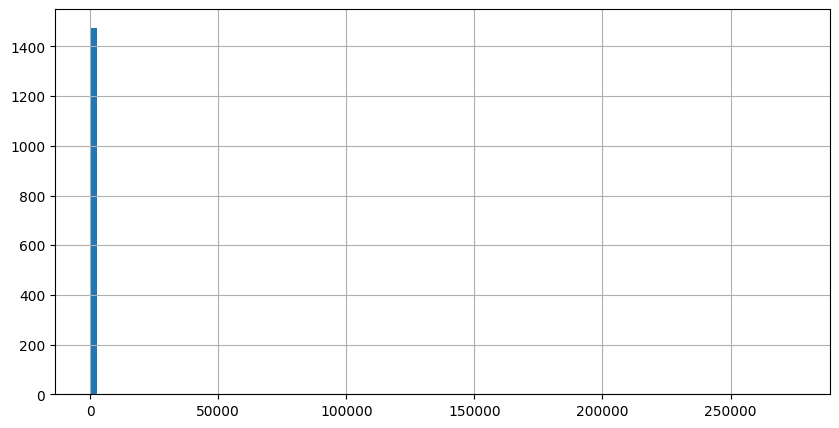

In [42]:
jobs_model["avg_salary"].hist(bins=100,figsize=(10,5))

#### **2.1.3 Detect Extreme Salary Values**

In [43]:
jobs_model.nlargest(20,"avg_salary")[
    [
        "job_title",
        "salary",
        "min_salary",
        "max_salary",
        "avg_salary",
        "source"
    ]
]

,job_title,salary,min_salary,max_salary,avg_salary,source
1848,Nhân Viên Idea Creator (Mảng POD - AI),"10,000,000 - 12,000,000 USD",250000.00,300000.00,275000.00,topcv
1602,Chuyên Viên SRE,"Tới 1,500,000 USD",0.00,37500.00,37500.00,topcv
3139,Solution Architect - Salary Up to $5000,Up to $5000,0.00,125.00,125.00,itviec
2082,Technical Manager (SaaS),"Tới 4,000 USD",0.00,100.00,100.00,topcv
3175,VIETTEL SOLUTIONS - Solutions Architect,"2,500 - 5,000 USD",62.50,125.00,93.75,itviec
2716,(HN) Expert/Manager Software Engineering,"3,000 - 4,000 USD",75.00,100.00,87.50,itviec
3155,Technical Lead (Golang) ~ Upto 3500$,Upto 3500$,0.00,87.50,87.50,itviec
3174,VIETTEL SOLUTIONS - Project Manager,"2,000 - 4,998 USD",50.00,124.95,87.47,itviec
2723,[HYBRID] Senior Java Developer,"3,200 - 3,500 USD",80.00,87.50,83.75,itviec
3092,Senior Python Developer,"3,200 - 3,500 USD",80.00,87.50,83.75,itviec


In [44]:
jobs_model[jobs_model["avg_salary"] > 500][
    [
        "job_title",
        "salary",
        "avg_salary",
        "source"
    ]
]

,job_title,salary,avg_salary,source
1602,Chuyên Viên SRE,"Tới 1,500,000 USD",37500.0,topcv
1848,Nhân Viên Idea Creator (Mảng POD - AI),"10,000,000 - 12,000,000 USD",275000.0,topcv


#### **2.1.4 Remove Salary Outliers**

In [45]:
bad_salary_mask = jobs_model["avg_salary"] > 500
jobs_model = jobs_model.loc[~bad_salary_mask].copy()
n_removed = bad_salary_mask.sum()
print(f"Removed {n_removed} salary outliers")

Removed 2 salary outliers


**Kết luận**

Các tin tuyển dụng có mức lương thỏa thuận không thể sử dụng cho bài toán hồi quy vì không có giá trị mục tiêu dạng số.

### **2.2 Final Salary Distribution Review**

Sau khi loại bỏ các bản ghi lương thỏa thuận và các outlier rõ ràng (>500 triệu VNĐ/tháng), phân phối lương được đánh giá lại trước khi xây dựng biến mục tiêu cho mô hình.

### **2.3 Log Transformation**

Phân phối lương vẫn lệch phải (right-skewed), điều này có thể ảnh hưởng đến các mô hình hồi quy tuyến tính.

Để giảm độ lệch và ổn định phương sai, nhóm áp dụng phép biến đổi:

> log_salary=log(1+avg_salary)

Việc biến đổi log giúp giảm độ lệch phải của phân phối lương và tạo điều kiện thuận lợi cho các mô hình hồi quy tuyến tính như `Ridge Regression`.

**Tạo biến mục tiêu**

In [46]:
jobs_model["log_salary"] = np.log1p(jobs_model["avg_salary"])
TARGET = "log_salary"

**Kiểm tra phân phối sau biến đổi**

In [47]:
jobs_model["log_salary"].describe()

count    1476.000000
mean        3.088477
std         0.658041
min         0.000000
25%         2.772589
50%         3.157000
75%         3.511545
max         4.836282
Name: log_salary, dtype: float64

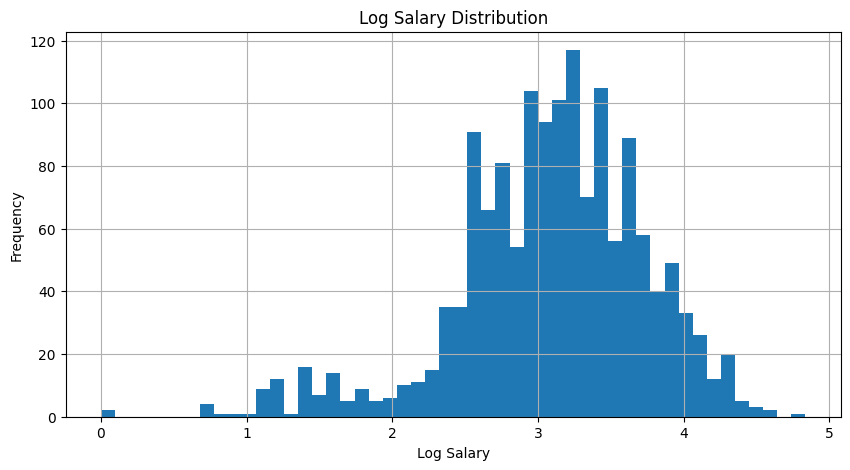

In [48]:
jobs_model["log_salary"].hist(bins=50,figsize=(10,5))
plt.title("Log Salary Distribution")
plt.xlabel("Log Salary")
plt.ylabel("Frequency")
plt.show()

In [49]:
print("Skewness before:",jobs_model["avg_salary"].skew())
print("Skewness after:",jobs_model["log_salary"].skew())

Skewness before: 1.332011920563557
Skewness after: -0.8372211851422461


## **SECTION 3 - Industry Cleaning Experiment**

### **3.1 Cardinality Analysis**

In [50]:
job_features = [
    "source",
    "location",
    "industry",
    "specialization",
    "education",
    "experience_years",
    "job_level",
    "standardized_title"
]

for col in job_features:
    print(f"{col}: {jobs_model[col].nunique()}")

source: 2
location: 18
industry: 55
specialization: 1154
education: 8
experience_years: 19
job_level: 9
standardized_title: 97


### **3.2 Industry Cleaning Experiment**

Mục tiêu của thí nghiệm này là giảm cardinality của biến industry
thông qua chuẩn hóa tên ngành và gộp các nhóm ngành hiếm.

Sau đó Ridge Regression sẽ được huấn luyện trên hai phiên bản dữ liệu:

* Industry gốc
* Industry đã được làm sạch

để đánh giá tác động của bước tiền xử lý này.

In [51]:
n_original = jobs_model["industry"].nunique()

print(f"Số lượng ngành nghề ban đầu: {n_original}")

print("\nTop 20 ngành nghề phổ biến nhất:")
print(
    jobs_model["industry"]
    .value_counts()
    .head(20)
)

counts = jobs_model["industry"].value_counts()

print(
    f"\nSố lượng ngành dưới 5 tin tuyển dụng: {(counts < 5).sum()}"
)

print(
    f"Số lượng ngành dưới 15 tin tuyển dụng: {(counts < 15).sum()}"
)

for k in [5, 10, 15, 20]:
    temp = group_rare_categories(
        jobs_model["industry"],
        min_freq=k
    )

    print(
        f"min_freq={k} -> "
        f"{temp.nunique()} nhóm ngành"
    )

Số lượng ngành nghề ban đầu: 55

Top 20 ngành nghề phổ biến nhất:
industry
IT - Phần mềm                            835
Giáo dục / Đào tạo                        54
IT Services and IT Consulting             49
Marketing / Truyền thông / Quảng cáo      47
Khác                                      35
Software Products and Web Services        32
Bán lẻ - Hàng tiêu dùng - FMCG            31
Viễn thông                                29
Sản xuất                                  27
Thương mại điện tử                        25
Financial Services                        22
Dược phẩm / Y tế / Công nghệ sinh học     21
IT - Phần cứng                            20
Tài chính                                 16
Software Development Outsourcing          14
Banking                                   14
Bất động sản                              14
Giải trí                                  13
Logistics - Vận tải                       11
Xây dựng                                  10
Name: count, dtype: int64

### **3.3 Decision**

Kết quả khảo sát cho thấy biến `industry` chứa nhiều nhóm xuất hiện rất ít lần.

Ngưỡng **min_freq=15** được lựa chọn vì giúp giảm đáng kể số lượng danh mục nhưng vẫn giữ lại phần lớn các nhóm ngành phổ biến.

Các ngành xuất hiện **dưới 15 lần** sẽ được gộp vào nhóm `Other`.

### **3.4 Create Industry Cleaned**

In [52]:
jobs_model["industry"] = clean_industry(
    jobs_model["industry"]
)

jobs_model["industry_cleaned"] = (
    group_rare_categories(
        jobs_model["industry"],
        min_freq=15
    )
)

print(
    "Original Industry:",
    jobs_model["industry"].nunique()
)

print(
    "Cleaned Industry:",
    jobs_model["industry_cleaned"].nunique()
)

Original Industry: 56
Cleaned Industry: 15


### **3.5 Salary Distribution by Industry Group**

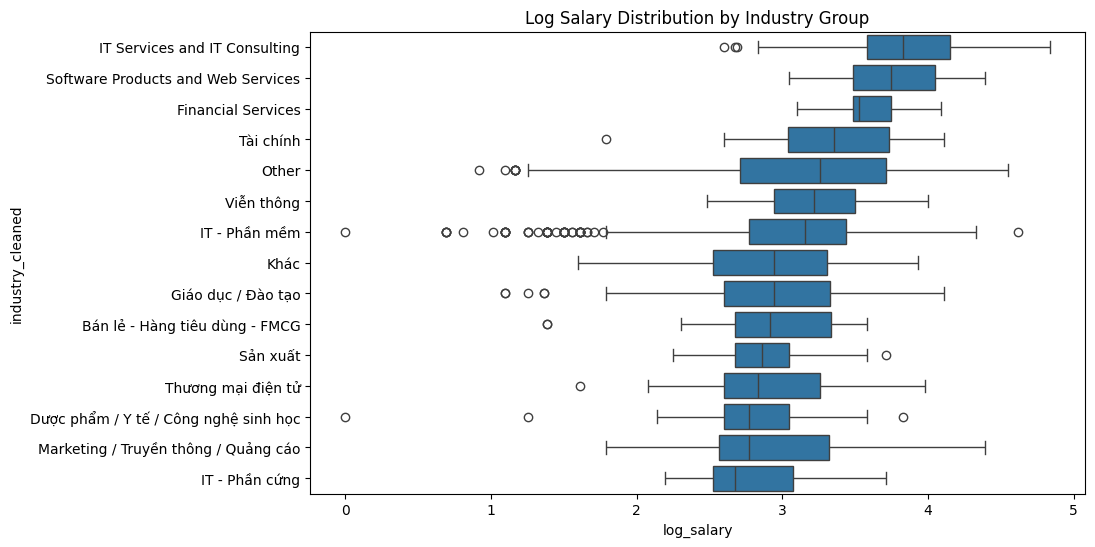

In [53]:
plt.figure(figsize=(10,6))

order = (
    jobs_model
    .groupby("industry_cleaned")["log_salary"]
    .median()
    .sort_values(ascending=False)
    .index
)

sns.boxplot(
    data=jobs_model,
    x="log_salary",
    y="industry_cleaned",
    order=order
)

plt.title(
    "Log Salary Distribution by Industry Group"
)

plt.show()

## **SECTION 4 - Feature Sets**

Để đánh giá tác động của bước làm sạch Industry, hai phiên bản **Feature Set A** được xây dựng.

* **Feature Set A (Original)**: sử dụng biến `industry`
* **Feature Set A (Cleaned)**: sử dụng biến `industry_cleaned`

Tất cả các đặc trưng còn lại được giữ nguyên.

In [54]:
FEATURES_A_ORIGINAL = [
    "source",
    "location",
    "industry",
    "education",
    "experience_years",
    "job_level",
    "standardized_title"
]

FEATURES_A_CLEANED = [
    "source",
    "location",
    "industry_cleaned",
    "education",
    "experience_years",
    "job_level",
    "standardized_title"
]

## **SECTION 5 - Modeling Dataset**

In [55]:
model_ready = jobs_model.copy()

X_original = model_ready[
    FEATURES_A_ORIGINAL
]

X_cleaned = model_ready[
    FEATURES_A_CLEANED
]

y = model_ready["log_salary"]

print(X_original.shape)
print(X_cleaned.shape)

(1476, 7)
(1476, 7)


### **Preprocessor Original**

In [56]:
cat_cols_original = [
    c for c in FEATURES_A_ORIGINAL
    if X_original[c].dtype == "object"
]

num_cols_original = [
    c for c in FEATURES_A_ORIGINAL
    if c not in cat_cols_original
]

preprocessor_original = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            cat_cols_original
        ),
        (
            "num",
            StandardScaler(),
            num_cols_original
        )
    ]
)

### **Preprocessor Cleaned**

In [57]:
cat_cols_cleaned = [
    c for c in FEATURES_A_CLEANED
    if X_cleaned[c].dtype == "object"
]

num_cols_cleaned = [
    c for c in FEATURES_A_CLEANED
    if c not in cat_cols_cleaned
]

preprocessor_cleaned = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            cat_cols_cleaned
        ),
        (
            "num",
            StandardScaler(),
            num_cols_cleaned
        )
    ]
)

## **SECTION 6 - Cross Validation Setup**

In [58]:
model_ready["salary_bin"] = pd.qcut(
    model_ready["avg_salary"],
    q=5,
    labels=False,
    duplicates="drop"
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

## **SECTION 7 - Ridge Hyperparameter Tuning**

Một giá trị alpha duy nhất được lựa chọn và sử dụng cho cả hai phiên bản dữ liệu nhằm đảm bảo tính công bằng khi so sánh.

In [59]:
alpha_grid = [
    0.01,
    0.1,
    1,
    10,
    100
]

alpha_results = tune_ridge_alpha(
    alphas=alpha_grid,
    X=X_original,
    y=y,
    cv=cv,
    stratify_labels=model_ready["salary_bin"],
    preprocessor=preprocessor_original
)

alpha_results.sort_values("mae_mean")

,alpha,mae_mean,mae_std,rmse_mean,rmse_std
3,10.00,0.272407,0.022841,0.367759,0.046842
2,1.00,0.273626,0.022794,0.373643,0.046483
1,0.10,0.278399,0.022154,0.381342,0.044714
0,0.01,0.279515,0.022043,0.383189,0.044389
4,100.00,0.295851,0.025349,0.397015,0.046947


In [60]:
# Chọn alpha tốt nhất
BEST_ALPHA = (alpha_results.sort_values("mae_mean").iloc[0]["alpha"])
BEST_ALPHA

np.float64(10.0)

## **SECTION 8 - Ridge Regression (Original Industry)**

### **8.2 Evaluation**

In [61]:
ridge_original = build_ridge_pipeline(
    preprocessor=preprocessor_original,
    alpha=BEST_ALPHA
)

In [62]:
ridge_original_results = evaluate_model(
    model=ridge_original,
    X=X_original,
    y=y,
    cv=cv,
    stratify_labels=model_ready["salary_bin"]
)

### **8.3 Summary**

In [63]:
ridge_original_summary = get_model_summary(
    ridge_original_results
)

ridge_original_summary

,mae,rmse
mean,0.272407,0.367759
std,0.022841,0.046842


## **SECTION 9 - Ridge Regression (Industry Cleaned)**

### **9.1 Build Pipeline**

In [64]:
ridge_cleaned = build_ridge_pipeline(
    preprocessor=preprocessor_cleaned,
    alpha=BEST_ALPHA
)

### **9.2 Evaluation**

In [65]:
ridge_cleaned_results = evaluate_model(
    model=ridge_cleaned,
    X=X_cleaned,
    y=y,
    cv=cv,
    stratify_labels=model_ready["salary_bin"]
)

### **9.3 Summary**

In [66]:
ridge_cleaned_summary = get_model_summary(
    ridge_cleaned_results
)

ridge_cleaned_summary

,mae,rmse
mean,0.273236,0.368090
std,0.022716,0.046478


## **SECTION 10 - Comparison**

### **10.1 MAE / RMSE Comparison**

In [67]:
comparison_df = pd.DataFrame({
    "version": [
        "Original Industry",
        "Industry Cleaned"
    ],
    "mae": [
        ridge_original_results["mae"].mean(),
        ridge_cleaned_results["mae"].mean()
    ],
    "rmse": [
        ridge_original_results["rmse"].mean(),
        ridge_cleaned_results["rmse"].mean()
    ]
})

comparison_df.sort_values("mae")

,version,mae,rmse
0,Original Industry,0.272407,0.367759
1,Industry Cleaned,0.273236,0.368090


### **10.2 Visualization**

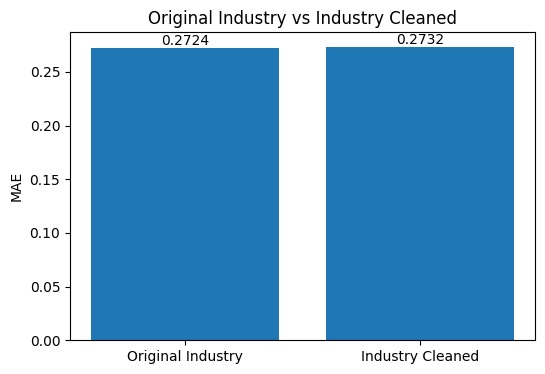

In [68]:
plt.figure(figsize=(6,4))

bars = plt.bar(
    comparison_df["version"],
    comparison_df["mae"]
)

for bar in bars:
    h = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        h,
        f"{h:.4f}",
        ha="center",
        va="bottom"
    )

plt.ylabel("MAE")
plt.title(
    "Original Industry vs Industry Cleaned"
)

plt.show()

## **SECTION 11 - Conclusion**

**Kết luận**

- Việc chuẩn hóa và gom nhóm biến `industry` giúp giảm số lượng danh mục hiếm và làm dữ liệu gọn hơn sau `One-Hot Encoding`.

- Tuy nhiên, kết quả thực nghiệm cho thấy phiên bản sử dụng `industry_cleaned` không cải thiện hiệu năng dự đoán so với biến `industry gốc`.

- Điều này cho thấy **Ridge Regression** vẫn khai thác hiệu quả thông tin từ các nhóm ngành hiếm và việc **giảm cardinality** của `industry` không mang lại lợi ích rõ ràng cho bài toán hiện tại.

> Do đó, biến `industry_cleaned` **không được sử dụng** trong notebook chính và Feature Set A cuối cùng vẫn giữ nguyên biến `industry gốc`.